# Small-signal stability analysis of the Kundur two-area system

This notebook computes the eigenvalues, damping ratios, participation factors and
mode shapes of a power system linearised about an operating point, using RAMSES
through the `stepss` package. The analysis runs inside the engine.

The system is Kundur's two-area, four-machine benchmark (Kundur, *Power System
Stability and Control*, McGraw-Hill 1994, Example 12.6). It is the standard test
case for inter-area oscillations: two symmetric areas joined by a weak tie, each
with two 900 MVA machines. We run it twice, with and without the power system
stabilisers, because the difference between those two runs is the clearest
possible demonstration that the analysis is doing something physically real.

## What "small-signal analysis" computes here

A dynamic power system model is a set of differential-algebraic equations. The
differential equations describe machine rotors, exciters and governors; the
algebraic equations describe the network, which has no dynamics of its own.
Linearised about an operating point, that is

$$\begin{aligned}
\Delta\dot{x} &= f_x\,\Delta x + f_y\,\Delta y \\
0 &= g_x\,\Delta x + g_y\,\Delta y
\end{aligned}$$

where $x$ are the states and $y$ the algebraic variables. Eliminating $\Delta y$
using the second equation gives the **state matrix**

$$A_{sys} = f_x - f_y\,g_y^{-1}\,g_x$$

whose eigenvalues are the system modes. This elimination is a Schur complement,
and it exists only if $g_y$ is nonsingular, which is what makes the model
index-1. RAMSES does all of this internally: it assembles the unreduced
Jacobian, factorises $g_y$ once with KLU, forms $A_{sys}$, and solves the dense
eigenproblem with LAPACK.

Each eigenvalue $\lambda = \sigma \pm j\omega$ is one mode:

- **frequency** $f = |\omega| / 2\pi$ in Hz,
- **damping ratio** $\zeta = -\sigma / |\lambda|$, which is the number engineers
  actually judge a mode by. $\zeta < 0$ means the oscillation grows: the
  operating point is unstable.

## Prerequisites, please read

**This needs RAMSES 3.79 or newer.** The `EIG` disturbance was added after 3.60,
and 3.79 changed both what it accepts and what it writes. Check with:

```python
import stepss; print(stepss.__version__)
```

The `stepss` version's leading components name the bundled RAMSES, so anything
from 3.79 onward carries what this notebook expects.

**What changed in 3.79.** `EIG` used to take an optional `real_limit` and
`pf_threshold` pair, and used `real_limit` to decide which modes got
participation factors and a mode shape written at all. That meant a mode you
could see in the modes file had nothing behind it, and widening the limit meant
running the case again. Both parameters are gone: **all three files now carry
every mode**, filtering happens here, in this notebook, against the results you
already have, and the only floor left is the `$PF_THRES` solver setting, which
bounds the one file that is quadratic in the state count.

A `.dst` still carrying the old pair is **refused**, not ignored, so an older
notebook or disturbance file fails loudly rather than answering a different
question. On an engine older than 3.79 the reads below still work, but the
participation and mode-shape files will hold only that engine's dominant modes.

**Everything below goes through `stepss.ssa`.** `ssa.run()` supplies the two
solver settings the analysis requires, clears any previous run under the same
basename, drives the engine and returns a result object; the filtering and the
plots are methods on it. The `EIG` disturbance record and the `sim.runSsa()`
entry both remain available to a caller who would rather drive the run
themselves.

In [1]:
import os

import matplotlib.pyplot as plt

import stepss
from stepss import ssa

print("stepss version:", stepss.__version__)

# Each variant runs in its own directory, because the results files are named
# from the basename and would otherwise overwrite each other.
os.makedirs("run_pss", exist_ok=True)
os.makedirs("run_nopss", exist_ok=True)

stepss version: 3.81


## Step 1: describe the case

A `cfg` object lists the input files. Three points that are easy to get wrong:

- **`solveroptions.dat` must set `$OMEGA_REF SYN`.** Under the default centre-of-inertia
  reference frame the engine refuses the analysis, because the COI equations are
  computed by finite differences at export time and never enter the assembled
  Jacobian, so reducing under COI would silently hold COI speed constant and
  give you a plausible, wrong answer. The engine refuses rather than doing that.
  The bundled `solveroptions.dat` already sets `SYN`, and `ssa.run()` supplies
  both records itself in a generated file read last, so a case of your own needs
  no edit.
- **`$SCHEME DE` is required too.** Under the integrated scheme the pure
  differential-algebraic values exist only briefly inside the Newton loop, so
  the analysis refuses there as well.
- **A disturbance file is mandatory even though we inject the disturbance from
  Python.** `nothing.dst` exists only to satisfy that requirement.

In [2]:
def build_case(dynfile, trj):
    """Assemble a Kundur case. `dynfile` selects the PSS variant."""
    case = stepss.cfg()
    case.addData("lf.dat")             # power flow: buses, lines, transformers
    case.addData(dynfile)              # dynamic data: machines, AVR/PSS, governors
    case.addData("solveroptions.dat")  # the case's own solver settings
    case.addDst("nothing.dst")
    case.addObs("obs.dat")
    case.addTrj(trj)
    return case


# The two variants differ in exactly one parameter: the PSS gain KSTAB, 20.0 in
# dyn.dat and 0.0 in dyn_noPSS.dat, on all four exciters. Everything else is
# identical, so any difference in the results is attributable to the PSS alone.
print(open("dyn.dat").readlines()[9].strip())
print(open("dyn_noPSS.dat").readlines()[9].strip())

EXC exc_kundur   0.01  200   1.0   1.0   20.0   10.0  0.05  0.02  3.0  5.4
EXC exc_kundur   0.01  200   1.0   1.0    0.0   10.0  0.05  0.02  3.0  5.4


## Step 2: run to the operating point and linearise there

`execSim(case, 0.0)` initialises the system and pauses at $t = 0$, the
pre-disturbance steady state. That is the operating point we linearise about.
Small-signal results are only meaningful *at* an operating point, so where you
pause determines what you get: pausing mid-swing linearises about a
non-equilibrium and the numbers describe that instant, not the steady state.

`addDisturb(t, "EIG 'basename'")` schedules the analysis. When the run reaches
`t`, RAMSES assembles the Jacobian, reduces it and writes three files named from
`basename`.

In [3]:
res_pss = ssa.run(build_case("dyn.dat", "out.trj"),
                  basename="ssa", workdir="run_pss")
res_nopss = ssa.run(build_case("dyn_noPSS.dat", "out.trj"),
                    basename="ssa", workdir="run_nopss")

res_nopss.summary()

ssa in /home/apetros/Code/stepss/stepss-python-ui/examples/eigenanalysis/run_nopss
  70 states, 96 algebraic variables, modes file v2
  linearised at t = 0.001 s
  70 modes, 50 simple, 20 degenerate
  participation written down to 0.001 ($PF_THRES)


## Step 3: read the modes

`<basename>_modes.dat` has one line per mode. The columns are:

| column | meaning |
|---|---|
| `index` | mode number, 1-based |
| `re`, `im` | real and imaginary parts of $\lambda$ |
| `zeta` | damping ratio $-\mathrm{Re}(\lambda)/|\lambda|$ |
| `freq_hz` | $|\mathrm{Im}(\lambda)|/2\pi$ |
| `smp` | **1 if the eigenvalue is simple, 0 if degenerate** |

The header records `nstates`, `nalg`, the time, `gap_tol`, and `pf_floor`, the
participation floor the run applied.

There is no `dom` column. Older files have one, between `freq_hz` and `smp`,
holding the engine's own verdict on whether a mode passed the `real_limit` it
was given. That verdict is now yours to make, at Step 4b, against every mode
rather than against the survivors of a threshold fixed before the run.
**The version is on the first line of the file, and the two layouts are
otherwise identical in width**, so a reader that ignores the banner does not
fail: it reads `smp` out of the `dom` column and answers wrongly.

**The `smp` column deserves attention, because ignoring it produces
confident nonsense.** Power system spectra are heavily degenerate: identical
machine models with identical parameters produce identical poles, and this
4-machine system has 20 of its 70 modes sharing an eigenvalue with another mode.
In a degenerate eigenspace the individual eigenvectors are *not unique*, so the
participation factors and mode shape of such a mode are basis-dependent. They
are real numbers that mean nothing physically and would come out differently on
another LAPACK build. Treat `smp == 0` rows as unusable for participation
analysis. The header records the gap tolerance used to decide.


In [4]:
for tag, res in (("with PSS", res_pss), ("without PSS", res_nopss)):
    print("%-12s %3d modes, %3d simple, %3d degenerate"
          % (tag, len(res.modes), int(res.modes["simple"].sum()),
             int((~res.modes["simple"]).sum())))

with PSS      70 modes,  62 simple,   8 degenerate
without PSS   70 modes,  50 simple,  20 degenerate


## Step 4: find the electromechanical modes

Rotor oscillations in a system like this sit roughly between 0.1 and 2.5 Hz.
Below that are slow controller modes, above it exciter and network dynamics.
We take one member of each conjugate pair, by keeping only $\mathrm{Im}(\lambda) > 0$.

In [5]:
for tag, res in (("WITH PSS", res_pss), ("WITHOUT PSS", res_nopss)):
    print("\n%s" % tag)
    res.electromechanical().table()


WITH PSS
  mode   f [Hz]    zeta        lambda                     simple
  22     0.1040    +0.9996     -24.3370 +0.6536j          yes
  41     0.1372    +0.9839     -4.7500 +0.8621j           yes
  39     0.1392    +0.9838     -4.7944 +0.8744j           yes
  45     0.1486    +0.7046     -0.9269 +0.9336j           yes
  35     0.6237    +0.1087     -0.4287 +3.9190j           yes
  27     1.2424    +0.2880     -2.3481 +7.8065j           yes
  25     1.2950    +0.2865     -2.4331 +8.1365j           yes

WITHOUT PSS
  mode   f [Hz]    zeta        lambda                     simple
  37     0.1279    +0.9876     -5.0573 +0.8034j           yes
  35     0.1303    +0.9871     -5.0501 +0.8185j           yes
  41     0.1342    +0.3528     -0.3179 +0.8433j           yes
  31     0.6246    -0.0233     +0.0914 +3.9245j           yes
  25     1.0850    +0.0990     -0.6781 +6.8172j           yes
  23     1.1161    +0.0966     -0.6809 +7.0128j           yes


### Step 4b: the real part limit

`electromechanical()` above filters by frequency. The other filter worth having
is on the real part, and it is the one that used to be a parameter of the run:
`EIG` took a `real_limit`, the engine flagged every mode against it, and wrote
participation factors and mode shapes for the survivors alone.

That is now a question you ask of results you already have, which matters
because it is a question you rarely get right first time. Widening the limit
used to mean running the case again.

Two things it is good for. It is the honest way to cut a spectrum down to the
modes with the least damping, and it is what makes the s-plane readable: a
handful of fast, well-damped modes far out to the left stretch the real axis
until everything worth looking at is squashed against the boundary. The same
filter drives the **real part above** tick in STEPSS GUI, and the reset there is
its zoom control.


In [6]:
for limit in (-1.0, -0.5, -0.1):
    kept = res_pss.dominant(limit)
    print("real part above %-6g : %2d of %d modes, leftmost Re = %+.2f"
          % (limit, len(kept), len(res_pss.modes), kept.rows["re"].min()))

print("\nunfiltered, the spectrum reaches Re = %+.1f" % res_pss.modes["re"].min())

real part above -1     : 17 of 70 modes, leftmost Re = -1.00
real part above -0.5   : 14 of 70 modes, leftmost Re = -0.43
real part above -0.1   :  2 of 70 modes, leftmost Re = -0.05

unfiltered, the spectrum reaches Re = -301.9


## Step 5: the result that matters

Look at the mode near **0.62 Hz** in both tables.

- Without the PSS its damping ratio is about **-0.023**: negative, so the
  oscillation grows and the operating point is small-signal unstable.
- With the PSS it is about **+0.109**: comfortably damped.

That is the inter-area mode, in which the two areas swing against each other,
and it is the mode the stabilisers exist to damp. The sign flip is the whole
point of the exercise, and it reproduces Kundur's Example 12.6.

The two local modes near 1.1 Hz are the machines within each area swinging
against each other. They are damped in both cases, and the PSS pushes them
higher in frequency and much better damped.

In [7]:
def interarea(res, lo=0.4, hi=0.9):
    """The single mode in the inter-area band."""
    band = res.electromechanical(lo, hi)
    assert len(band) == 1, "expected one inter-area mode, found %d" % len(band)
    return band[0]


print("inter-area mode")
for tag, res in (("without PSS", res_nopss), ("with    PSS", res_pss)):
    mode = interarea(res)
    print("  %s: f = %.4f Hz, zeta = %+.4f  -> %s"
          % (tag, mode["freq"], mode["zeta"],
             "UNSTABLE" if mode["zeta"] < 0 else "stable"))

inter-area mode
  without PSS: f = 0.6246 Hz, zeta = -0.0233  -> UNSTABLE
  with    PSS: f = 0.6237 Hz, zeta = +0.1087  -> stable


## Step 6: participation factors, or which machines are involved

An eigenvalue tells you a mode exists. It does not tell you *where* it lives.
The participation factor of state $k$ in mode $i$,

$$p_{ki} = |w_{ki}\, v_{ki}|$$

built from the left and right eigenvectors, measures how strongly that state
takes part. RAMSES normalises each mode's column so its largest entry is 1, which
removes the arbitrary scaling of the eigenvectors.

`<basename>_pf.dat` carries these, one row per (mode, state) pair, with the
family, device and variable name inlined so you do not have to cross-reference
anything.

**Rows are written for every mode.** This is the file the `real_limit`
parameter used to restrict, and the reason it was worth restricting: it is the
one output quadratic in the state count, one row per (mode, state) pair, so at
the engine's 5000-state ceiling an unfloored file would be 25 million rows. What
bounds it now is `$PF_THRES`, a solver setting that defaults to `1e-3` and is
recorded in the modes header as `pf_floor`. That is a size guard, not a
judgement about which entries matter: normalisation puts one entry at exactly 1
in every mode, so no mode can be emptied by it however high it is set.

Looking at the `omega` states, one per machine rotor, tells you which machines
swing in each mode.


In [8]:
def omega_rows(res, mode, floor):
    """Rotor-speed participation of each machine in one mode."""
    return [(row.device.strip(), row.pf)
            for row in res.participation(mode, floor=floor)
            if row.variable == "omega"]


print("omega participation, without PSS\n")
mode = interarea(res_nopss)
print("  inter-area %.3f Hz:" % mode["freq"])
for device, pf in sorted(omega_rows(res_nopss, mode, 0.05)):
    print("    %-6s %.3f" % (device, pf))

for local in res_nopss.electromechanical(0.9, 2.5):
    print("\n  local mode %.3f Hz:" % local["freq"])
    for device, pf in sorted(omega_rows(res_nopss, local, 0.05)):
        print("    %-6s %.3f" % (device, pf))

# The same mode with the floor dropped: the other area's machines were in the
# file all along, two orders of magnitude below the participating pair. Nothing
# was re-run to see them.
local = res_nopss.electromechanical(0.9, 2.5)[0]
print("\n  the same mode at floor 0.001:")
for device, pf in sorted(omega_rows(res_nopss, local, 0.001)):
    print("    %-6s %.3f" % (device, pf))

omega participation, without PSS

  inter-area 0.625 Hz:
    G1     0.861
    G2     0.523
    G3     1.000
    G4     0.875

  local mode 1.085 Hz:
    G1     0.839
    G2     0.995

  local mode 1.116 Hz:
    G3     0.844
    G4     0.994

  the same mode at floor 0.001:
    G1     0.839
    G2     0.995
    G3     0.042
    G4     0.018


Read that output carefully, because it is the physical interpretation the whole
analysis exists to support:

- the **inter-area** mode lists all four machines, with substantial
  participation from each;
- the **1.085 Hz** mode lists only G1 and G2, so it is area 1's local mode;
- the **1.116 Hz** mode lists only G3 and G4, the mirror image in area 2.

**Note what the absence means.** The listing above is cut at a threshold this
notebook chose, not one the engine imposed. G3 and G4 are missing from the
1.085 Hz mode because their participation is around 0.02 to 0.04 against roughly
1.0 for the area-1 machines, so two orders of magnitude separate the
participating machines from the rest. That is a decisive separation, not a
marginal one, and you can see it for yourself by passing a smaller `floor`
below: the rows are already in the file, so nothing has to be re-run.

Only below `pf_floor`, recorded in the modes header, is an entry genuinely
absent from the file rather than merely filtered here.

If your own model produces a mode you cannot attribute, participation factors
are the tool that tells you which device to go and look at.


## Step 7: mode shapes, or how the machines move relative to each other

`<basename>_ms.dat` gives the rotor-speed component of each machine in a mode,
as magnitude and angle, **for every mode**. Magnitudes are normalised so the
largest is 1, and **angles are relative to that largest entry**, because an
eigenvector's absolute phase is arbitrary and would otherwise vary run to run.

This file used to be restricted to dominant modes as well. It needs no floor of
its own: it carries one row per machine per mode, which is linear in the state
count rather than quadratic.

For an inter-area mode the expected picture is two groups roughly 180 degrees
apart: the areas swinging against each other.


inter-area mode shape, without PSS

  G1     magnitude 0.845   angle  +168.55 deg
  G2     magnitude 0.571   angle  +179.98 deg
  G3     magnitude 1.000   angle    +0.00 deg
  G4     magnitude 0.928   angle    -2.78 deg


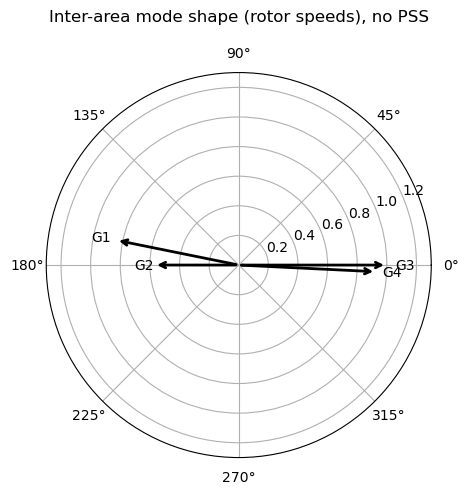

In [9]:
mode = interarea(res_nopss)
print("inter-area mode shape, without PSS\n")
for row in res_nopss.mode_shape(mode):
    print("  %-6s magnitude %.3f   angle %+8.2f deg"
          % (row.device.strip(), row.magnitude, row.angle_deg))

ax = res_nopss.mode_shape_plot(mode)
ax.set_title("Inter-area mode shape (rotor speeds), no PSS", pad=18)
plt.show()

The two areas sit roughly opposite each other on the dial. That is what
"inter-area" means, made visible.

## Step 8: the s-plane

The conventional summary plot. The vertical axis is oscillation frequency, the
horizontal axis is decay rate. **Everything strictly left of the imaginary axis
is stable**; anything on or right of it is not. The dashed rays mark constant
damping ratio, the usual planning criterion being $\zeta \geq 0.05$.

s-plane drawn without interaction: this backend has no window to update. Use %matplotlib widget for click-to-select and drag-to-zoom.
s-plane drawn without interaction: this backend has no window to update. Use %matplotlib widget for click-to-select and drag-to-zoom.


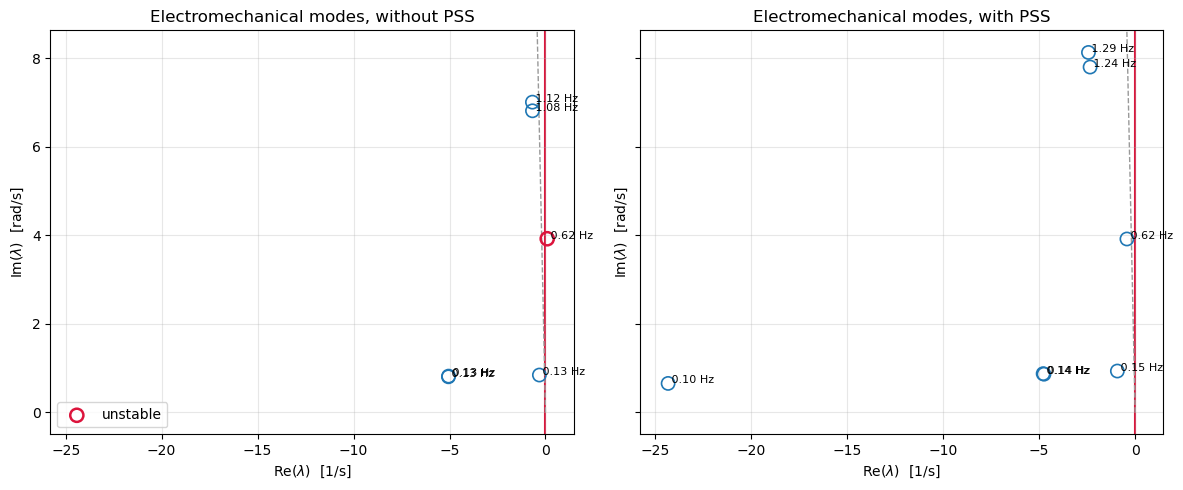

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, (tag, res) in zip(axes, (("without PSS", res_nopss), ("with PSS", res_pss))):
    res.electromechanical().splane(ax=ax)
    ax.set_title("Electromechanical modes, %s" % tag)
plt.tight_layout()
plt.show()

### The whole spectrum, and why the limit is worth having

The two panels above show the electromechanical band, which is already a
narrow window. Plot all 70 modes and the problem the real part limit solves
becomes visible: the fast controller and network modes sit far out to the left,
the axis stretches to hold them, and the modes the analysis is actually about
collapse into a stripe against the boundary.

The left panel below is the honest full spectrum. The right one is the same
data through `dominant()`, and nothing has been re-run to produce it.


s-plane drawn without interaction: this backend has no window to update. Use %matplotlib widget for click-to-select and drag-to-zoom.
s-plane drawn without interaction: this backend has no window to update. Use %matplotlib widget for click-to-select and drag-to-zoom.


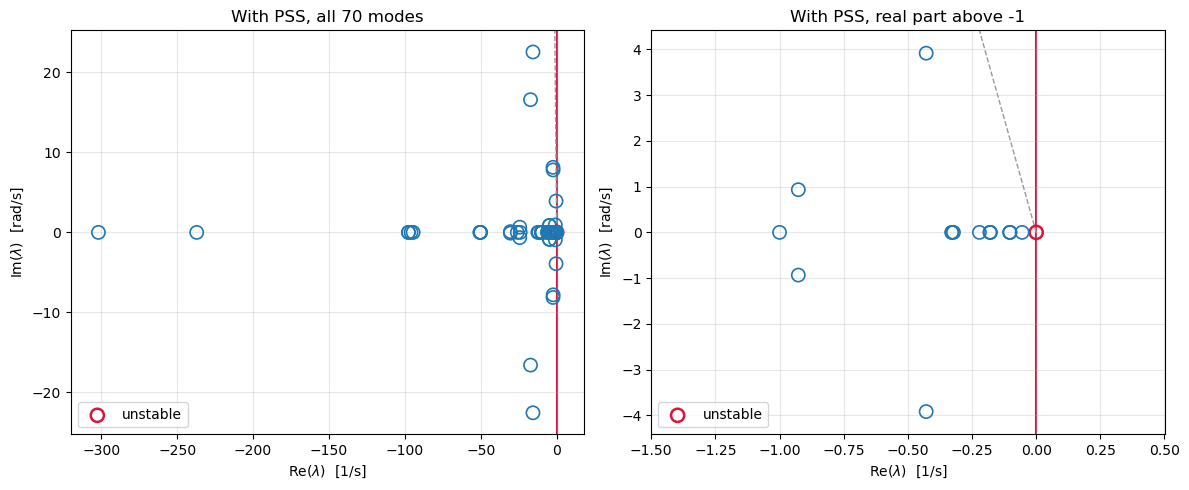

full spectrum   Re from  -301.87 to  +0.00
above -1        Re from    -1.00 to  +0.00   (17 modes)


In [11]:
LIMIT = -1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
res_pss.splane(ax=axes[0], annotate=False)
axes[0].set_title("With PSS, all %d modes" % len(res_pss.modes))
res_pss.dominant(LIMIT).splane(ax=axes[1], annotate=False)
axes[1].set_title("With PSS, real part above %g" % LIMIT)
plt.tight_layout()
plt.show()

print("full spectrum   Re from %+8.2f to %+6.2f"
      % (res_pss.modes["re"].min(), res_pss.modes["re"].max()))
kept = res_pss.dominant(LIMIT)
print("above %-6g    Re from %+8.2f to %+6.2f   (%d modes)"
      % (LIMIT, kept.rows["re"].min(), kept.rows["re"].max(), len(kept)))

Without the PSS one mode sits to the *right* of the red line. That single point
is the whole result: the operating point is small-signal unstable, and a
disturbance would excite a growing 0.62 Hz oscillation between the two areas.

## Where to go next

- Change the PSS gain `KSTAB` in `dyn.dat` and watch the inter-area mode move.
- Stress the tie line in `lf.dat` by raising the transfer, and watch damping fall.
- Analyse at several operating points by re-running the whole flow per point.
  **Finalise each run with `endSim()` before loading the next case**: a paused
  simulation is not finished, and loading a new case without finalising silently
  resumes the old one.
- Try the same run in STEPSS GUI. The results window applies both filters live,
  its **real part above** tick being `dominant()` and its **PF at least** field
  the floor used in Step 6, and its s-plane zooms by dragging a rectangle.
- For systems above a few thousand states the engine refuses the dense solve, by
  design, and reports the `$EIG_MAX_STATES` limit. That regime needs sparse
  shift-invert methods, which `scipy.sparse.linalg.eigs` can drive from the
  Jacobian returned by `getJac()`
- Read the reduced state matrix directly with `res.state_matrix` and drive
  your own eigensolver over it.